In [69]:
import numpy as np
from sklearn.datasets import load_iris, make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV


In [79]:
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=200, noise=0.2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


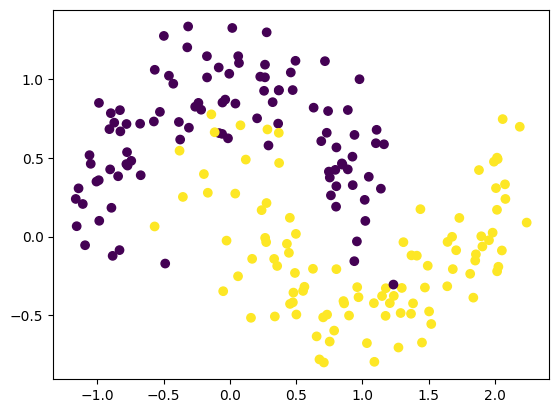

In [80]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:, 1], c=y)

In [81]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LinearSVC(loss="hinge", max_iter=10000))
])

grid_param = {
    "classifier__C" : [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(param_grid=grid_param, estimator=model, cv=3)
grid_search.fit(X_train, y_train)
model = grid_search.best_estimator_
print(grid_search.best_params_)

{'classifier__C': 0.1}


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [82]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = model.predict(X_test)

# # Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)



Accuracy: 0.925


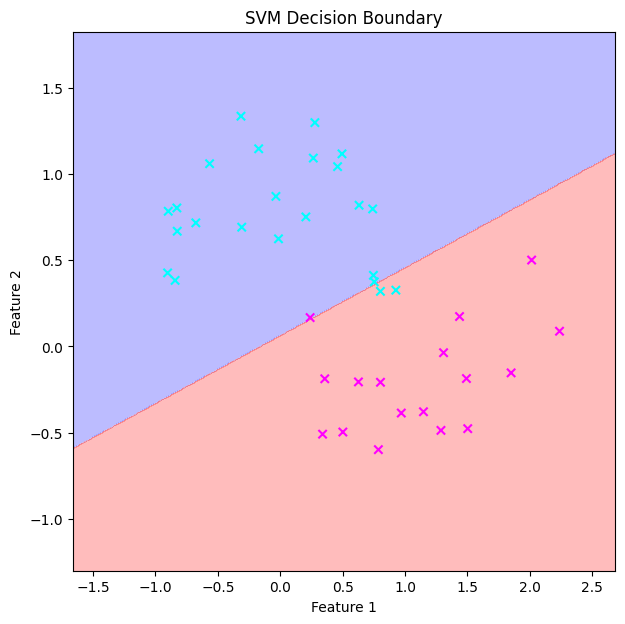

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# Fit your model (already done)
# model = grid_search.best_estimator_

# Create a meshgrid over feature space
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Predict on meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(7,7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
# plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='bwr', edgecolor='k')
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='cool', marker='x')  # optional: test points
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary")
plt.show()
